In [1]:
from ref import *
from read_complex_matrix import read_complex_matrix
from calculating_dynamic_resolution import *
import pandas as pd
import numpy as np
import torch
import torch.optim as optim
torch.set_printoptions(precision=4)

matr = read_complex_matrix('ref_matrix.txt')
import timeit

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [2]:
import numpy as np
import math
from variables import *

data = np.loadtxt('experiment.txt')
r1 = data[:, 1] - data[:, 2]
r = data[:, 1]
sigma = sigma+0.0
Ibkg=Ibkg+0.0
I0_plus = np.mean(r[r > 0.9*r1[0]][0:1+math.ceil(len(r[r > 0.9*r1[0]])*0.7)])
I0 = torch.tensor(I0_plus).requires_grad_(True) - Ibkg

In [3]:
%%time
q = dynamic_mesh_q(kmax, Ndots, gap)

r, r_conv= reflectometry(q, matr, 10*sigma, 6*sigma, I0, Ibkg)

CPU times: total: 15.6 ms
Wall time: 15.1 ms


In [4]:
len(r)

80

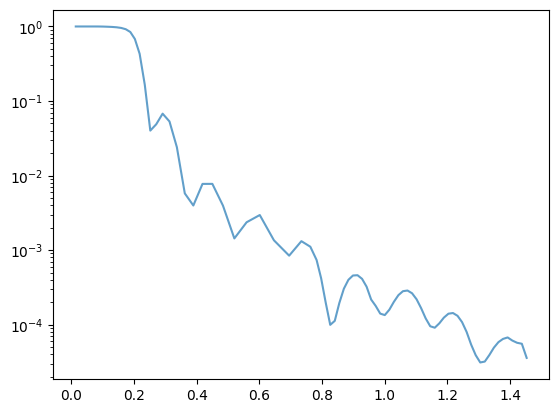

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

ax.plot(q.cpu().detach().numpy()[0:len(r_conv.tolist())]*1e-9, r_conv.tolist(), alpha=0.7)

ax.set_yscale('log')

plt.show()

In [6]:
from objective_function import *

loss_function = Comparator(q, matr, 10*sigma, 6*sigma, I0, Ibkg)

objective_function = varbounds(all_bounds, loss_function.compare)
objective_function_weightless = varbounds(all_bounds, loss_function.compare_weightless)

ModuleNotFoundError: No module named 'objective_function'

In [ ]:
initial_d = torch.tensor([444.7000,  42.0000, 125.7000,  27.3000], requires_grad=True)
initial_rho = torch.tensor([7.9000,  -1.9000], requires_grad=True)
initial_sigma = torch.tensor(0.01, requires_grad=True)

I_bounds =  torch.tensor([0.92*I0 , 1.08*I0]).requires_grad_(True)
Ibkg_bounds = torch.tensor([0.0, 3*Ibkg]).requires_grad_(True)

initial_sigma1 = torch.nn.Parameter(torch.tensor(0.136, dtype=torch.float64))
initial_sigma2 = torch.nn.Parameter(torch.tensor(0.026, dtype=torch.float64))
sigma_bounds1 =  torch.tensor([0.13 , 0.15]).requires_grad_(True)
sigma_bounds2 =  torch.tensor([0.01 , 0.03]).requires_grad_(True)

sigma_bounds = [[(0.05 * sigma).detach().item(), (15 * sigma).detach().item()],
          [(0.05 * sigma).detach().item(), (15 * sigma).detach().item()]]

In [ ]:
from optimizer import *
ans_d, ans_rho, ans_I, ans_Ibkg, loss, rel_losses1 = adamw(q, r_conv, objective_function.objective_function, initial_sigma1, initial_sigma2,
                                                                      initial_d, initial_rho, 1.06*I0, Ibkg, 
                                                                      d_bounds, rho_bounds,I_bounds, Ibkg_bounds,
                                                                      lr= 0.005, max_iter = 120, k=3)


In [ ]:
objective_function_sigma = varsigma(ans_d, ans_rho, ans_I, ans_Ibkg, loss_function.compare, all_bounds)

In [ ]:
from scipy.optimize import differential_evolution as de

bounds = [[(0.05 * sigma).detach().item(), (15 * sigma).detach().item()],
          [(0.05 * sigma).detach().item(), (15 * sigma).detach().item()]]

ans_sigma1, ans_sigma2 = de(
    func=objective_function_sigma.objective_function,
    bounds=bounds
).x

In [ ]:
ans_d, ans_rho, ans_I, ans_Ibkg, loss, rel_losses2 = adamw(q, r_conv, objective_function_weightless.objective_function, 
                                                                      ans_sigma1, ans_sigma2,
                                                                      ans_d, ans_rho, ans_I, ans_Ibkg, 
                                                                      d_bounds, rho_bounds, I_bounds, Ibkg_bounds,
                                                                      lr= 0.0008, max_iter = 60, k=2)

In [ ]:
objective_function_weightless_sigma = varsigma(ans_d, ans_rho, ans_I, ans_Ibkg, loss_function.compare_weightless, all_bounds)
ans_sigma1, ans_sigma2 = de(
    func=objective_function_weightless_sigma.objective_function,
    bounds=bounds,
).x

ans_d, ans_rho, ans_I, ans_Ibkg, loss, rel_losses3 = adamw(q, r_conv, objective_function_weightless.objective_function, 
                                                                      ans_sigma1, ans_sigma2,
                                                                      ans_d, ans_rho, ans_I, ans_Ibkg, 
                                                                      d_bounds, rho_bounds, I_bounds, Ibkg_bounds,
                                                                      lr= 0.0005, max_iter = 200, k=2)

In [ ]:
rel_losses2 = list(map(lambda x: x * rel_losses1[-1],  rel_losses2))
rel_losses3 = list(map(lambda x: x * rel_losses2[-1],  rel_losses3))
rel_losses = rel_losses1 + rel_losses2 + rel_losses3

In [ ]:
fig, ax = plt.subplots(figsize =(15, 4))

ax.plot(range(0,len(rel_losses)), rel_losses, label='AdamW')

ax.set_yscale('log')
ax.legend()
plt.grid()
plt.show()